# Exploring Adaptive Homogeneity for Morse Potentials

This notebook explores the hypothesis that the "effective homogeneity degree" $k_{\text{eff}}(r)$ provides a simpler, more universal representation of interatomic potentials than the energy surface itself.

## Key Questions
1. Does $k_{\text{eff}}$ collapse to a universal curve under reduced coordinates?
2. How does the singularity at $V=0$ behave?
3. What is the natural sign convention?

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd

# Plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Define the Morse Potential

The standard Morse potential is:
$$V(r) = D_e \left(1 - e^{-a(r-r_e)}\right)^2$$

where:
- $D_e$ = well depth (dissociation energy)
- $r_e$ = equilibrium bond length  
- $a$ = controls the width/stiffness of the well

The force is:
$$F(r) = -\frac{dV}{dr} = -2 D_e a (1 - e^{-a(r-r_e)}) e^{-a(r-r_e)}$$

In [14]:
def morse_potential(r, De, a, re):
    """Standard Morse potential."""
    x = 1 - np.exp(-a * (r - re))
    return De * x**2

def morse_derivative(r, De, a, re):
    """dV/dr for Morse potential."""
    exp_term = np.exp(-a * (r - re))
    return 2 * De * a * (1 - exp_term) * exp_term

def morse_force(r, De, a, re):
    """Force F = -dV/dr."""
    return -morse_derivative(r, De, a, re)

def k_eff(r, De, a, re, epsilon=1e-10):
    """
    Effective homogeneity degree: k_eff = (r * V') / V
    
    For a homogeneous function of degree d, this equals d everywhere.
    For Morse, it varies with r.
    """
    V = morse_potential(r, De, a, re)
    dV = morse_derivative(r, De, a, re)
    
    # Handle singularity where V -> 0
    with np.errstate(divide='ignore', invalid='ignore'):
        k = (r * dV) / V
        # Mark singular points as NaN for now (we'll analyze these)
        k[np.abs(V) < epsilon] = np.nan
    return k

## 2. Visualize Basic Morse Behavior

First, let's look at a typical Morse potential and understand its structure.

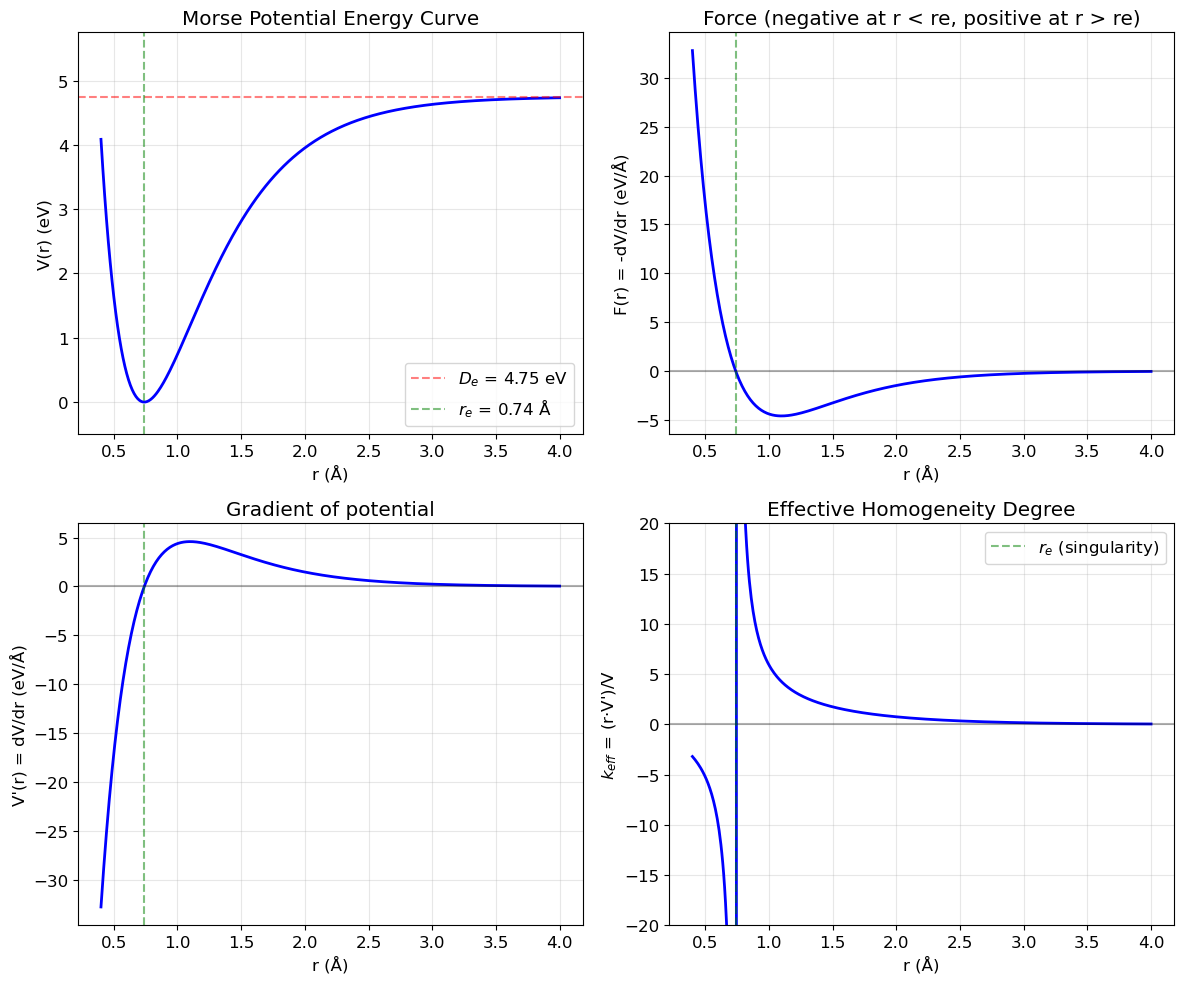

Stiffness parameter a·re = 1.428


In [15]:
# Example parameters (roughly like H2)
De = 4.75  # eV
re = 0.74  # Angstrom
a = 1.93   # 1/Angstrom

r = np.linspace(0.4, 4.0, 500)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Potential energy curve
ax = axes[0, 0]
V = morse_potential(r, De, a, re)
ax.plot(r, V, 'b-', linewidth=2)
ax.axhline(De, color='r', linestyle='--', alpha=0.5, label=f'$D_e$ = {De} eV')
ax.axvline(re, color='g', linestyle='--', alpha=0.5, label=f'$r_e$ = {re} Å')
ax.set_xlabel('r (Å)')
ax.set_ylabel('V(r) (eV)')
ax.set_title('Morse Potential Energy Curve')
ax.legend()
ax.set_ylim(-0.5, De + 1)

# Plot 2: Force
ax = axes[0, 1]
F = morse_force(r, De, a, re)
ax.plot(r, F, 'b-', linewidth=2)
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.axvline(re, color='g', linestyle='--', alpha=0.5)
ax.set_xlabel('r (Å)')
ax.set_ylabel('F(r) = -dV/dr (eV/Å)')
ax.set_title('Force (negative at r < re, positive at r > re)')

# Plot 3: dV/dr (gradient)
ax = axes[1, 0]
dV = morse_derivative(r, De, a, re)
ax.plot(r, dV, 'b-', linewidth=2)
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.axvline(re, color='g', linestyle='--', alpha=0.5)
ax.set_xlabel('r (Å)')
ax.set_ylabel("V'(r) = dV/dr (eV/Å)")
ax.set_title('Gradient of potential')

# Plot 4: k_eff
ax = axes[1, 1]
k = k_eff(r, De, a, re)
ax.plot(r, k, 'b-', linewidth=2)
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.axvline(re, color='g', linestyle='--', alpha=0.5, label=f'$r_e$ (singularity)')
ax.set_xlabel('r (Å)')
ax.set_ylabel("$k_{eff}$ = (r·V')/V")
ax.set_title('Effective Homogeneity Degree')
ax.set_ylim(-20, 20)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Stiffness parameter a·re = {a * re:.3f}")

## 3. Understanding the Singularity

At $r = r_e$, we have $V(r_e) = 0$ but $V'(r_e) = 0$ too (it's a minimum). So we have a $0/0$ indeterminate form.

Let's analyze this using L'Hôpital's rule or Taylor expansion.

In [16]:
# Taylor expand around r = re
# Let x = r - re, so r = re + x
#
# V(r) = De * (1 - e^{-ax})^2
# For small x: e^{-ax} ≈ 1 - ax + (ax)^2/2 - ...
# So: 1 - e^{-ax} ≈ ax - (ax)^2/2 + ...
# And: V ≈ De * (ax)^2 = De * a^2 * x^2
#
# V'(r) = 2*De*a*(1-e^{-ax})*e^{-ax}
# For small x: V' ≈ 2*De*a*(ax)*(1) = 2*De*a^2*x
#
# So k_eff = r*V'/V = (re + x) * (2*De*a^2*x) / (De*a^2*x^2)
#          = (re + x) * 2 / x
#          = 2*re/x + 2
#
# As x -> 0: k_eff -> ±∞ (sign depends on direction of approach)

print("Near-equilibrium analysis:")
print("="*50)
print("\nTaylor expansion around r = re (let x = r - re):")
print("  V(r)  ≈ De·a²·x²")
print("  V'(r) ≈ 2·De·a²·x")
print("")
print("  k_eff = r·V'/V = (re + x)·(2·De·a²·x) / (De·a²·x²)")
print("        = 2·(re + x) / x")
print("        = 2·re/x + 2")
print("")
print("As x → 0⁺ (approaching from right): k_eff → +∞")
print("As x → 0⁻ (approaching from left):  k_eff → -∞")
print("")
print("This is a TRUE singularity (pole), not a removable one.")

Near-equilibrium analysis:

Taylor expansion around r = re (let x = r - re):
  V(r)  ≈ De·a²·x²
  V'(r) ≈ 2·De·a²·x

  k_eff = r·V'/V = (re + x)·(2·De·a²·x) / (De·a²·x²)
        = 2·(re + x) / x
        = 2·re/x + 2

As x → 0⁺ (approaching from right): k_eff → +∞
As x → 0⁻ (approaching from left):  k_eff → -∞

This is a TRUE singularity (pole), not a removable one.


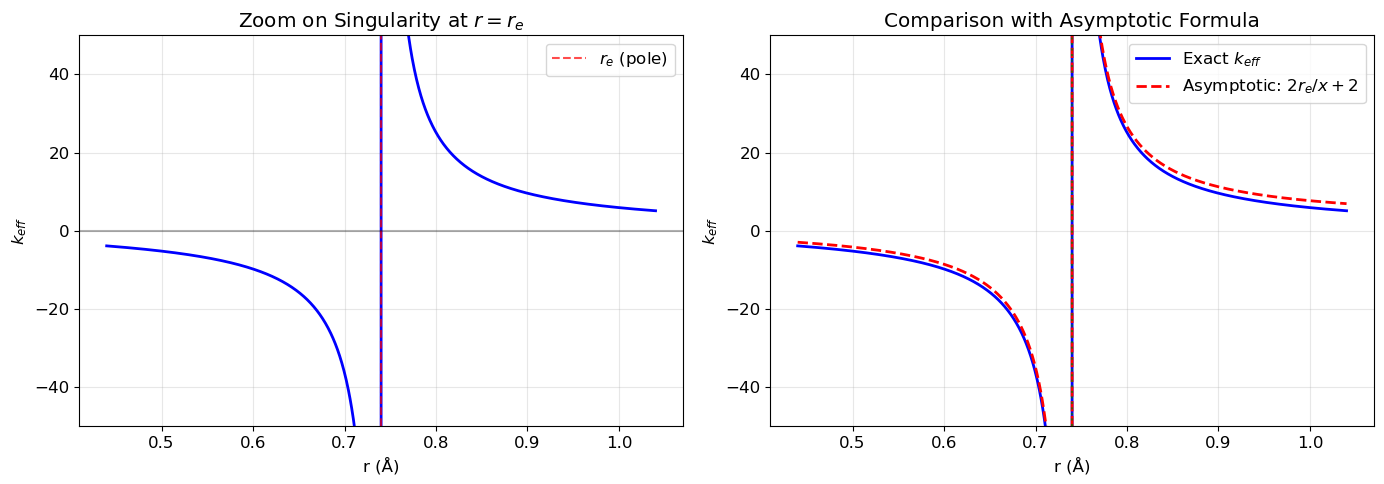

In [17]:
# Visualize the singularity structure more clearly
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Zoom in on the singularity
r_zoom = np.linspace(re - 0.3, re + 0.3, 1000)
k_zoom = k_eff(r_zoom, De, a, re)

ax = axes[0]
ax.plot(r_zoom, k_zoom, 'b-', linewidth=2)
ax.axvline(re, color='r', linestyle='--', alpha=0.7, label='$r_e$ (pole)')
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('r (Å)')
ax.set_ylabel('$k_{eff}$')
ax.set_title('Zoom on Singularity at $r = r_e$')
ax.set_ylim(-50, 50)
ax.legend()

# Show the asymptotic formula
ax = axes[1]
x = r_zoom - re
k_asymptotic = 2 * re / x + 2
ax.plot(r_zoom, k_zoom, 'b-', linewidth=2, label='Exact $k_{eff}$')
ax.plot(r_zoom, k_asymptotic, 'r--', linewidth=2, label='Asymptotic: $2r_e/x + 2$')
ax.axvline(re, color='g', linestyle=':', alpha=0.7)
ax.set_xlabel('r (Å)')
ax.set_ylabel('$k_{eff}$')
ax.set_title('Comparison with Asymptotic Formula')
ax.set_ylim(-50, 50)
ax.legend()

plt.tight_layout()
plt.show()

## 4. Test the "Corresponding States" Hypothesis

**Hypothesis**: If we plot $k_{eff}$ vs the reduced coordinate $r/r_e$, curves with the same "stiffness parameter" $\alpha = a \cdot r_e$ should collapse.

Let's test this systematically.

In [18]:
def generate_morse_family(n_curves=5, stiffness_target=1.5, De_range=(1, 10), re_range=(0.5, 3.0)):
    """
    Generate a family of Morse potentials with the SAME stiffness parameter α = a·re
    but different De and re values.
    
    If corresponding states works, their k_eff vs r/re curves should overlap.
    """
    curves = []
    
    # Sample different re values
    re_values = np.linspace(re_range[0], re_range[1], n_curves)
    
    for re in re_values:
        # Fix stiffness: a = stiffness_target / re
        a = stiffness_target / re
        # Random De (shouldn't matter for k_eff shape)
        De = np.random.uniform(De_range[0], De_range[1])
        
        curves.append({
            'De': De,
            're': re,
            'a': a,
            'stiffness': a * re  # Should equal stiffness_target
        })
    
    return curves

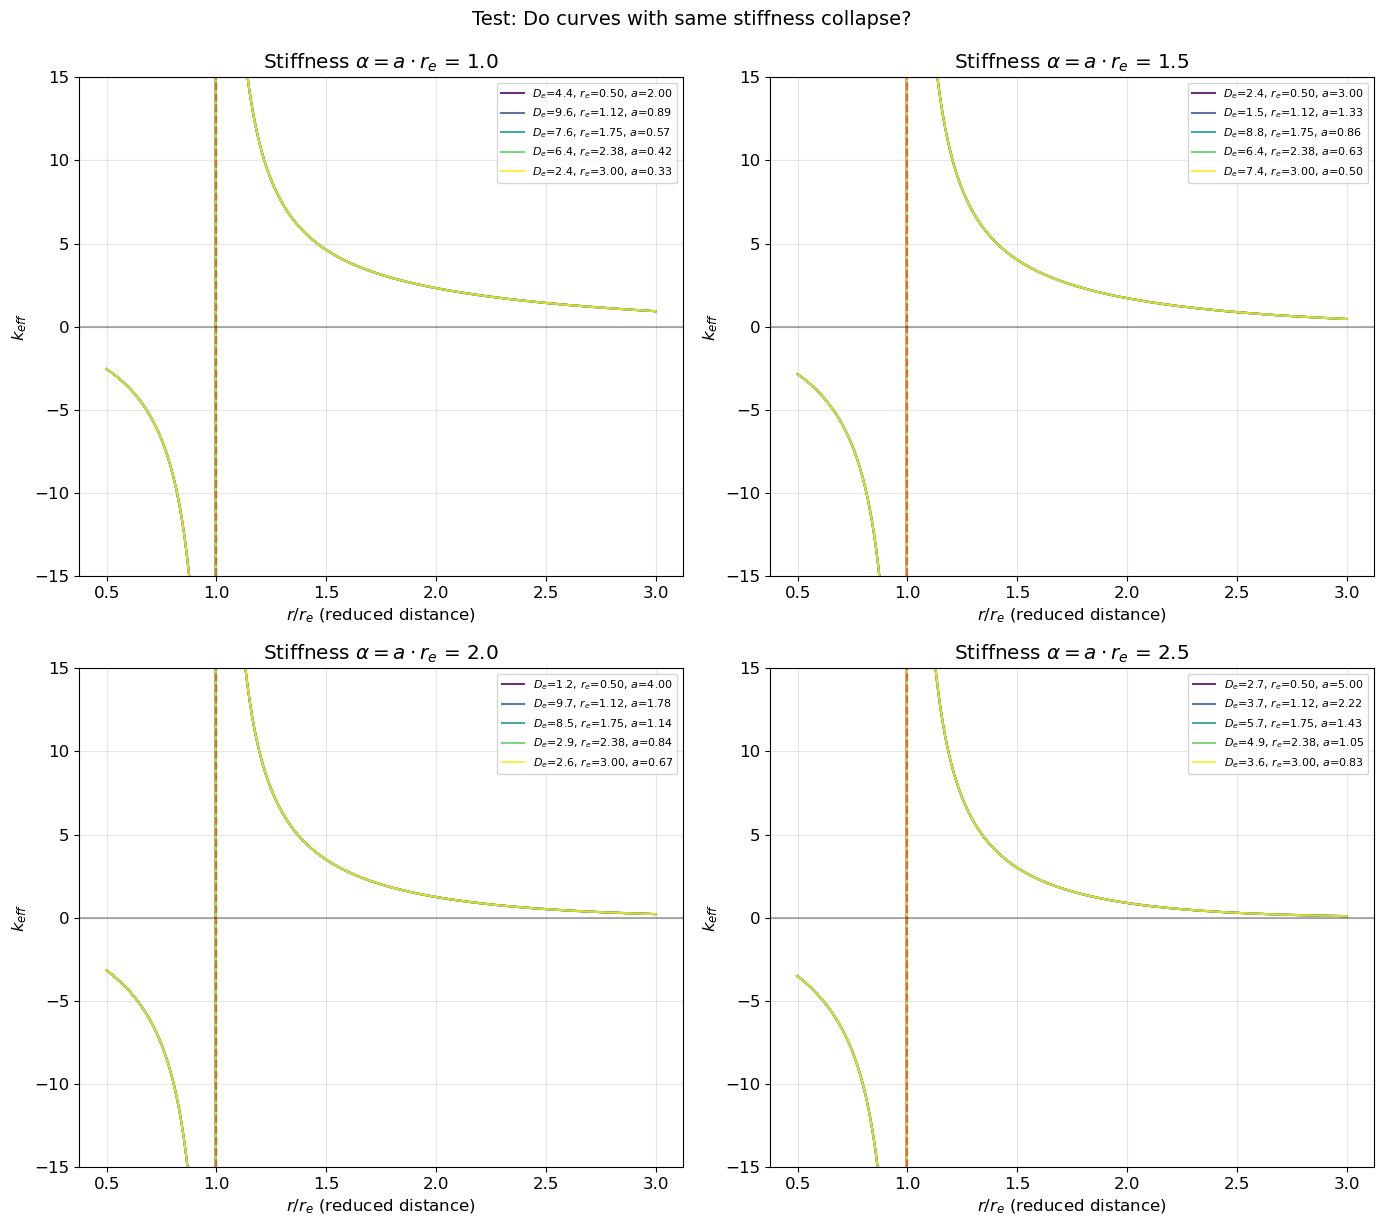

In [19]:
# Test 1: Same stiffness, different (De, re, a)
np.random.seed(42)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

stiffness_values = [1.0, 1.5, 2.0, 2.5]
colors = cm.viridis(np.linspace(0, 1, 5))

for idx, stiffness in enumerate(stiffness_values):
    ax = axes[idx // 2, idx % 2]
    
    curves = generate_morse_family(n_curves=5, stiffness_target=stiffness)
    
    for i, curve in enumerate(curves):
        De, re, a = curve['De'], curve['re'], curve['a']
        
        # Use reduced coordinate r/re
        r_reduced = np.linspace(0.5, 3.0, 500)  # r/re from 0.5 to 3.0
        r_actual = r_reduced * re
        
        k = k_eff(r_actual, De, a, re)
        
        label = f'$D_e$={De:.1f}, $r_e$={re:.2f}, $a$={a:.2f}'
        ax.plot(r_reduced, k, color=colors[i], linewidth=1.5, 
                label=label, alpha=0.8)
    
    ax.axvline(1.0, color='r', linestyle='--', alpha=0.5)
    ax.axhline(0, color='k', linestyle='-', alpha=0.3)
    ax.set_xlabel('$r/r_e$ (reduced distance)')
    ax.set_ylabel('$k_{eff}$')
    ax.set_title(f'Stiffness $\\alpha = a \\cdot r_e$ = {stiffness}')
    ax.set_ylim(-15, 15)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.suptitle('Test: Do curves with same stiffness collapse?', y=1.02, fontsize=14)
plt.show()

## 5. Analytical Derivation of $k_{eff}$ in Reduced Coordinates

Let's derive $k_{eff}$ analytically to understand the collapse (or lack thereof).

In [20]:
# Analytical derivation
print("Analytical form of k_eff in reduced coordinates")
print("="*60)
print("")
print("Let ρ = r/re (reduced distance)")
print("Let α = a·re (stiffness parameter)")
print("")
print("Then r - re = re(ρ - 1), so a(r - re) = α(ρ - 1)")
print("")
print("V(r) = De·(1 - e^{-α(ρ-1)})²")
print("")
print("V'(r) = dV/dr = (dV/dρ)·(dρ/dr) = (dV/dρ)·(1/re)")
print("")
print("dV/dρ = 2·De·α·(1 - e^{-α(ρ-1)})·e^{-α(ρ-1)}")
print("")
print("So V'(r) = (2·De·α/re)·(1 - e^{-α(ρ-1)})·e^{-α(ρ-1)}")
print("")
print("k_eff = r·V'/V = (ρ·re)·V'(r) / V(r)")
print("")
print("Let u = e^{-α(ρ-1)}, so (1 - u) appears in both.")
print("")
print("k_eff = (ρ·re)·(2·De·α/re)·(1-u)·u / [De·(1-u)²]")
print("      = 2·α·ρ·u / (1-u)")
print("      = 2·α·ρ·e^{-α(ρ-1)} / (1 - e^{-α(ρ-1)})")
print("")
print("KEY RESULT:")
print("-----------")
print("k_eff(ρ; α) = 2α·ρ·e^{-α(ρ-1)} / (1 - e^{-α(ρ-1)})")
print("")
print("This depends ONLY on ρ = r/re and α = a·re, NOT on De!")
print("")
print("→ The 'Corresponding States' hypothesis IS CORRECT for Morse.")
print("→ De scales out completely.")

Analytical form of k_eff in reduced coordinates

Let ρ = r/re (reduced distance)
Let α = a·re (stiffness parameter)

Then r - re = re(ρ - 1), so a(r - re) = α(ρ - 1)

V(r) = De·(1 - e^{-α(ρ-1)})²

V'(r) = dV/dr = (dV/dρ)·(dρ/dr) = (dV/dρ)·(1/re)

dV/dρ = 2·De·α·(1 - e^{-α(ρ-1)})·e^{-α(ρ-1)}

So V'(r) = (2·De·α/re)·(1 - e^{-α(ρ-1)})·e^{-α(ρ-1)}

k_eff = r·V'/V = (ρ·re)·V'(r) / V(r)

Let u = e^{-α(ρ-1)}, so (1 - u) appears in both.

k_eff = (ρ·re)·(2·De·α/re)·(1-u)·u / [De·(1-u)²]
      = 2·α·ρ·u / (1-u)
      = 2·α·ρ·e^{-α(ρ-1)} / (1 - e^{-α(ρ-1)})

KEY RESULT:
-----------
k_eff(ρ; α) = 2α·ρ·e^{-α(ρ-1)} / (1 - e^{-α(ρ-1)})

This depends ONLY on ρ = r/re and α = a·re, NOT on De!

→ The 'Corresponding States' hypothesis IS CORRECT for Morse.
→ De scales out completely.


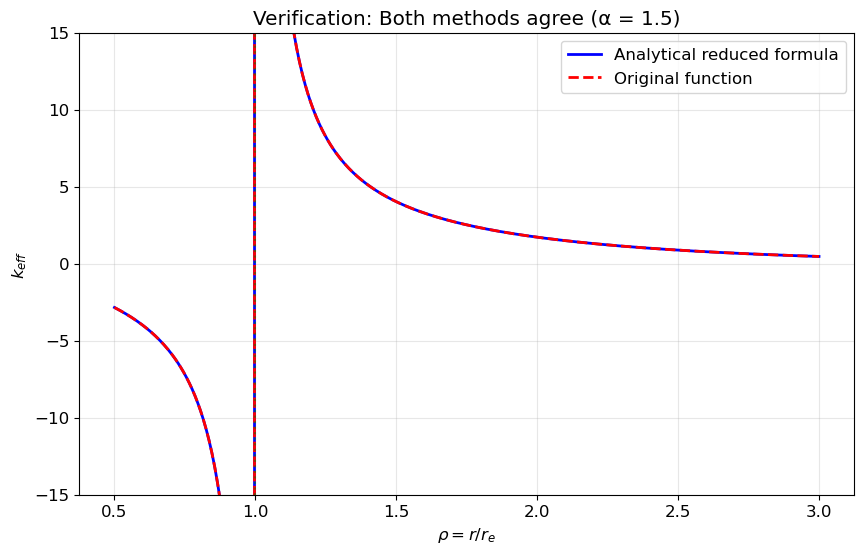

Max difference: 2.27e-13


In [21]:
def k_eff_reduced(rho, alpha, epsilon=1e-10):
    """
    k_eff as a function of reduced coordinate ρ = r/re and stiffness α = a·re.
    
    k_eff(ρ; α) = 2α·ρ·e^{-α(ρ-1)} / (1 - e^{-α(ρ-1)})
    """
    u = np.exp(-alpha * (rho - 1))
    
    with np.errstate(divide='ignore', invalid='ignore'):
        k = 2 * alpha * rho * u / (1 - u)
        # Handle singularity at ρ = 1 (where u = 1)
        k[np.abs(1 - u) < epsilon] = np.nan
    
    return k

# Verify this matches the original computation
rho = np.linspace(0.5, 3.0, 500)
alpha = 1.5

# Method 1: Direct formula
k1 = k_eff_reduced(rho, alpha)

# Method 2: Via original function with specific parameters
De_test, re_test = 5.0, 2.0
a_test = alpha / re_test
r_test = rho * re_test
k2 = k_eff(r_test, De_test, a_test, re_test)

plt.figure(figsize=(10, 6))
plt.plot(rho, k1, 'b-', linewidth=2, label='Analytical reduced formula')
plt.plot(rho, k2, 'r--', linewidth=2, label='Original function')
plt.axvline(1.0, color='g', linestyle=':', alpha=0.5)
plt.xlabel('$\\rho = r/r_e$')
plt.ylabel('$k_{eff}$')
plt.title(f'Verification: Both methods agree (α = {alpha})')
plt.ylim(-15, 15)
plt.legend()
plt.show()

# Check they match (ignoring NaN)
mask = ~(np.isnan(k1) | np.isnan(k2))
print(f"Max difference: {np.max(np.abs(k1[mask] - k2[mask])):.2e}")

## 6. Universal Curves: How $k_{eff}$ Varies with Stiffness

Now let's see how the universal curve changes with the stiffness parameter $\alpha$.

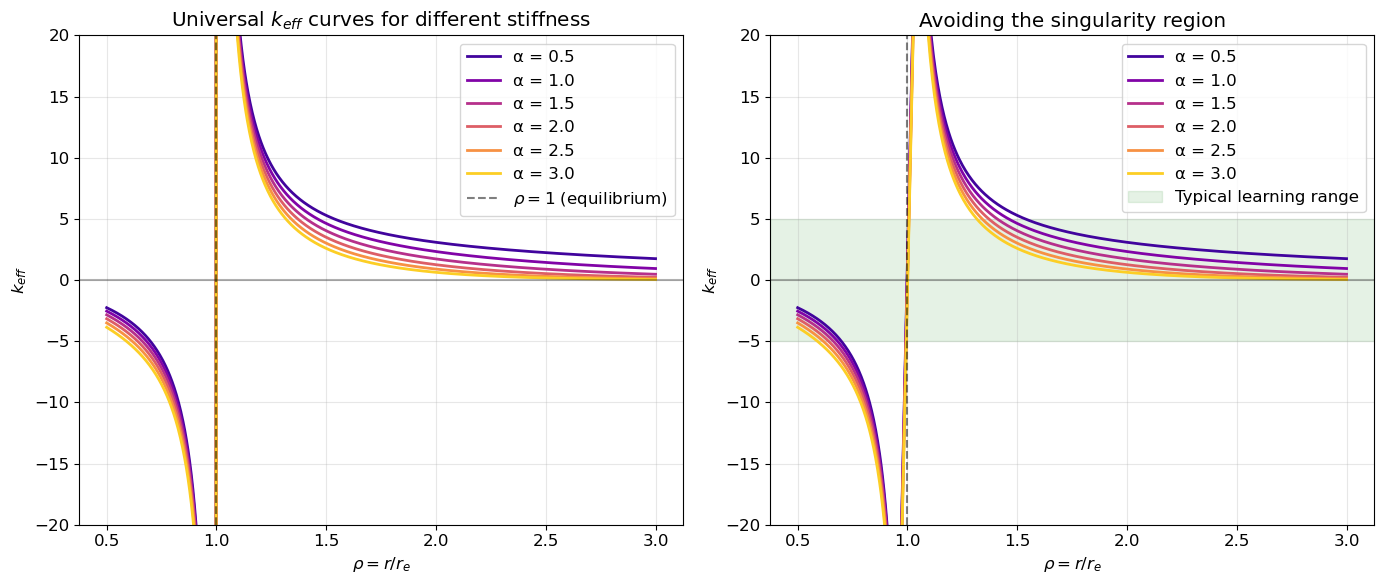

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rho = np.linspace(0.5, 3.0, 1000)
alphas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
colors = cm.plasma(np.linspace(0.1, 0.9, len(alphas)))

# Left: Full view
ax = axes[0]
for alpha, color in zip(alphas, colors):
    k = k_eff_reduced(rho, alpha)
    ax.plot(rho, k, color=color, linewidth=2, label=f'α = {alpha}')

ax.axvline(1.0, color='k', linestyle='--', alpha=0.5, label='$ρ = 1$ (equilibrium)')
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('$ρ = r/r_e$')
ax.set_ylabel('$k_{eff}$')
ax.set_title('Universal $k_{eff}$ curves for different stiffness')
ax.set_ylim(-20, 20)
ax.legend()

# Right: Focus on the "learnable" region away from singularity
ax = axes[1]
rho_safe = np.concatenate([np.linspace(0.5, 0.95, 200), np.linspace(1.05, 3.0, 400)])

for alpha, color in zip(alphas, colors):
    k = k_eff_reduced(rho_safe, alpha)
    ax.plot(rho_safe, k, color=color, linewidth=2, label=f'α = {alpha}')

ax.axvline(1.0, color='k', linestyle='--', alpha=0.5)
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.axhspan(-5, 5, alpha=0.1, color='green', label='Typical learning range')
ax.set_xlabel('$ρ = r/r_e$')
ax.set_ylabel('$k_{eff}$')
ax.set_title('Avoiding the singularity region')
ax.set_ylim(-20, 20)
ax.legend()

plt.tight_layout()
plt.show()

## 7. The Singularity Problem: Potential Solutions

The pole at $\rho = 1$ is a fundamental issue. Let's explore possible remedies.

In [23]:
print("Singularity Analysis and Potential Solutions")
print("="*60)
print("")
print("The problem: k_eff = 2α·ρ·u/(1-u) has a pole at ρ=1 (where u=1)")
print("")
print("Near ρ=1, let ρ = 1 + ε:")
print("  u = e^{-αε} ≈ 1 - αε + (αε)²/2 - ...")
print("  1 - u ≈ αε")
print("  k_eff ≈ 2α(1+ε)·(1-αε) / (αε) ≈ 2(1+ε)/ε = 2/ε + 2")
print("")
print("This is a SIMPLE POLE with residue 2 (independent of α!)")
print("")
print("-" * 60)
print("POSSIBLE SOLUTIONS:")
print("-" * 60)
print("")
print("1. POLE SUBTRACTION: Learn k_eff - 2/(ρ-1) instead")
print("   This subtracts the known pole structure.")
print("")
print("2. REGULARIZED FORM: Multiply by (ρ-1) to get")
print("   g(ρ) = (ρ-1)·k_eff = 2α·ρ·(ρ-1)·u/(1-u)")
print("   This has a REMOVABLE singularity (g(1) = 2).")
print("")
print("3. ENERGY-SHIFTED FORM: Use V(r) - De instead of V(r)")
print("   (shifts zero point to dissociation limit)")
print("")
print("4. EXCLUDE EQUILIBRIUM: Only learn k_eff for |ρ-1| > δ")
print("   and use analytical continuation near equilibrium.")

Singularity Analysis and Potential Solutions

The problem: k_eff = 2α·ρ·u/(1-u) has a pole at ρ=1 (where u=1)

Near ρ=1, let ρ = 1 + ε:
  u = e^{-αε} ≈ 1 - αε + (αε)²/2 - ...
  1 - u ≈ αε
  k_eff ≈ 2α(1+ε)·(1-αε) / (αε) ≈ 2(1+ε)/ε = 2/ε + 2

This is a SIMPLE POLE with residue 2 (independent of α!)

------------------------------------------------------------
POSSIBLE SOLUTIONS:
------------------------------------------------------------

1. POLE SUBTRACTION: Learn k_eff - 2/(ρ-1) instead
   This subtracts the known pole structure.

2. REGULARIZED FORM: Multiply by (ρ-1) to get
   g(ρ) = (ρ-1)·k_eff = 2α·ρ·(ρ-1)·u/(1-u)
   This has a REMOVABLE singularity (g(1) = 2).

3. ENERGY-SHIFTED FORM: Use V(r) - De instead of V(r)
   (shifts zero point to dissociation limit)

4. EXCLUDE EQUILIBRIUM: Only learn k_eff for |ρ-1| > δ
   and use analytical continuation near equilibrium.


In [24]:
def k_eff_regularized(rho, alpha):
    """
    Regularized form: g(ρ) = (ρ-1)·k_eff
    
    g(ρ) = 2α·ρ·(ρ-1)·e^{-α(ρ-1)} / (1 - e^{-α(ρ-1)})
    
    At ρ=1, this has limit g(1) = 2 (L'Hôpital's rule)
    """
    u = np.exp(-alpha * (rho - 1))
    
    # Use stable formula for (ρ-1)/(1-u) near ρ=1
    # (ρ-1)/(1-e^{-α(ρ-1)}) -> 1/α as ρ->1
    
    with np.errstate(divide='ignore', invalid='ignore'):
        # Direct computation
        g = 2 * alpha * rho * (rho - 1) * u / (1 - u)
        
        # Handle the limit at ρ=1
        near_one = np.abs(rho - 1) < 1e-6
        g[near_one] = 2  # The analytical limit
    
    return g


def k_eff_pole_subtracted(rho, alpha):
    """
    Pole-subtracted form: h(ρ) = k_eff - 2/(ρ-1)
    
    This removes the pole, leaving a smooth function.
    """
    k = k_eff_reduced(rho, alpha)
    pole = 2 / (rho - 1)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        h = k - pole
        # At ρ=1, need L'Hôpital: h(1) = lim[k_eff - 2/(ρ-1)]
        # This equals 2 (the constant term in the expansion)
        near_one = np.abs(rho - 1) < 1e-6
        h[near_one] = 2
    
    return h

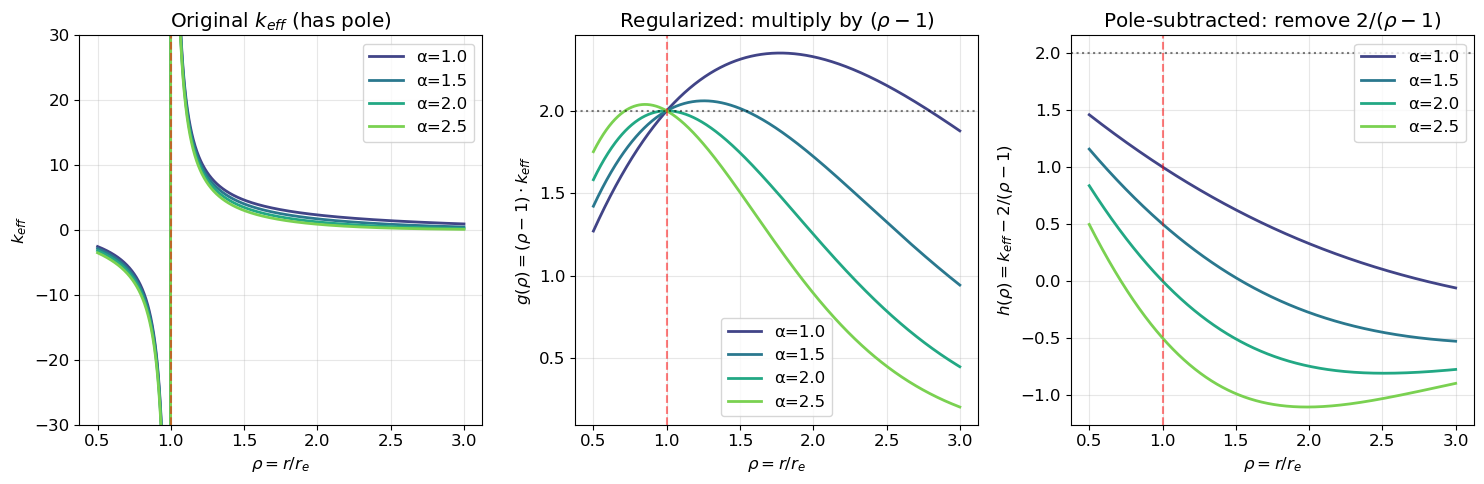

Both regularization methods produce SMOOTH functions!
The regularized forms are much more amenable to ML.


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

rho = np.linspace(0.5, 3.0, 1000)
alphas = [1.0, 1.5, 2.0, 2.5]
colors = cm.viridis(np.linspace(0.2, 0.8, len(alphas)))

# Original k_eff (with singularity)
ax = axes[0]
for alpha, color in zip(alphas, colors):
    k = k_eff_reduced(rho, alpha)
    ax.plot(rho, k, color=color, linewidth=2, label=f'α={alpha}')
ax.set_xlabel('$ρ = r/r_e$')
ax.set_ylabel('$k_{eff}$')
ax.set_title('Original $k_{eff}$ (has pole)')
ax.set_ylim(-30, 30)
ax.legend()
ax.axvline(1, color='r', linestyle='--', alpha=0.5)

# Regularized form g = (ρ-1)·k_eff
ax = axes[1]
for alpha, color in zip(alphas, colors):
    g = k_eff_regularized(rho, alpha)
    ax.plot(rho, g, color=color, linewidth=2, label=f'α={alpha}')
ax.set_xlabel('$ρ = r/r_e$')
ax.set_ylabel('$g(ρ) = (ρ-1) \\cdot k_{eff}$')
ax.set_title('Regularized: multiply by $(ρ-1)$')
ax.legend()
ax.axvline(1, color='r', linestyle='--', alpha=0.5)
ax.axhline(2, color='k', linestyle=':', alpha=0.5, label='g(1)=2')

# Pole-subtracted form h = k_eff - 2/(ρ-1)
ax = axes[2]
for alpha, color in zip(alphas, colors):
    h = k_eff_pole_subtracted(rho, alpha)
    ax.plot(rho, h, color=color, linewidth=2, label=f'α={alpha}')
ax.set_xlabel('$ρ = r/r_e$')
ax.set_ylabel('$h(ρ) = k_{eff} - 2/(ρ-1)$')
ax.set_title('Pole-subtracted: remove $2/(ρ-1)$')
ax.legend()
ax.axvline(1, color='r', linestyle='--', alpha=0.5)
ax.axhline(2, color='k', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("Both regularization methods produce SMOOTH functions!")
print("The regularized forms are much more amenable to ML.")

## 8. Recovery: Can We Get V(r) Back from k_eff?

The integration formula is:
$$V(r) = V(r_0) \exp\left(\int_{r_0}^{r} \frac{k_{eff}(x)}{x} dx\right)$$

Using the boundary condition $V(\infty) = D_e$.

In [26]:
from scipy.integrate import cumulative_trapezoid

def recover_V_from_keff(r, k_eff_values, V_ref, r_ref):
    """
    Recover V(r) from k_eff using:
    V(r) = V(r_ref) * exp(∫_{r_ref}^{r} k_eff(x)/x dx)
    
    Parameters:
    -----------
    r : array, distance values (must be sorted)
    k_eff_values : array, k_eff at each r
    V_ref : float, reference potential value
    r_ref : float, reference distance (should be in r array)
    """
    # Compute the integrand k_eff(r)/r
    integrand = k_eff_values / r
    
    # Cumulative integral from r[0]
    integral = np.zeros_like(r)
    integral[1:] = cumulative_trapezoid(integrand, r)
    
    # Find the reference point
    ref_idx = np.argmin(np.abs(r - r_ref))
    integral_at_ref = integral[ref_idx]
    
    # Shift integral so it's zero at r_ref
    integral = integral - integral_at_ref
    
    # Recover V
    V_recovered = V_ref * np.exp(integral)
    
    return V_recovered

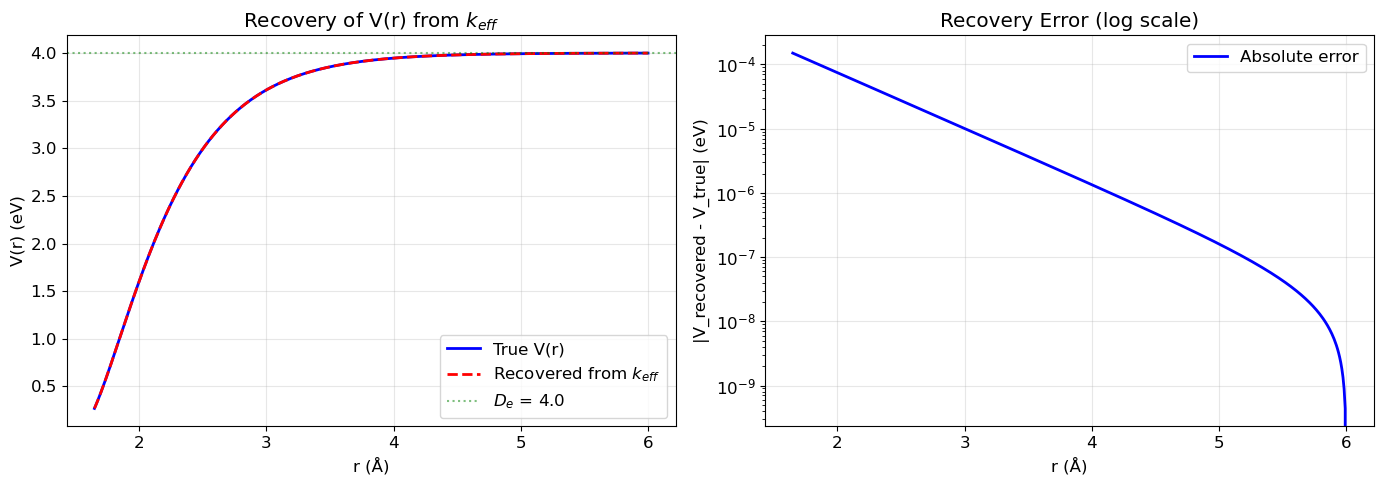

Reference: V(6.00) = 3.9990 eV (true De = 4.0)
Max absolute error: 1.50e-04 eV
Max relative error: 0.06%


In [27]:
# Test recovery on a known Morse potential
De, re, a = 4.0, 1.5, 2.0

# Use points AWAY from the singularity
r = np.linspace(1.1 * re, 4 * re, 500)  # Start above re to avoid singularity

# True values
V_true = morse_potential(r, De, a, re)
k_values = k_eff(r, De, a, re)

# Reference point: use large r where V ≈ De
r_ref = 4 * re
V_ref = morse_potential(r_ref, De, a, re)  # Should be close to De

# Recover V
V_recovered = recover_V_from_keff(r, k_values, V_ref, r_ref)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(r, V_true, 'b-', linewidth=2, label='True V(r)')
ax.plot(r, V_recovered, 'r--', linewidth=2, label='Recovered from $k_{eff}$')
ax.axhline(De, color='g', linestyle=':', alpha=0.5, label=f'$D_e$ = {De}')
ax.set_xlabel('r (Å)')
ax.set_ylabel('V(r) (eV)')
ax.set_title('Recovery of V(r) from $k_{eff}$')
ax.legend()

ax = axes[1]
error = np.abs(V_recovered - V_true)
relative_error = error / np.maximum(V_true, 1e-10) * 100
ax.semilogy(r, error, 'b-', linewidth=2, label='Absolute error')
ax.set_xlabel('r (Å)')
ax.set_ylabel('|V_recovered - V_true| (eV)')
ax.set_title('Recovery Error (log scale)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Reference: V({r_ref:.2f}) = {V_ref:.4f} eV (true De = {De})")
print(f"Max absolute error: {np.max(error):.2e} eV")
print(f"Max relative error: {np.max(relative_error):.2f}%")

## 9. The "Virial Plot": Visualizing Non-Homogeneity

For a homogeneous function of degree $d$: $r \cdot F(r) = -d \cdot V(r)$

Plotting $r \cdot F$ vs $V$ should give a straight line through the origin with slope $-d$.

For Morse, we expect a CURVE (not a line).

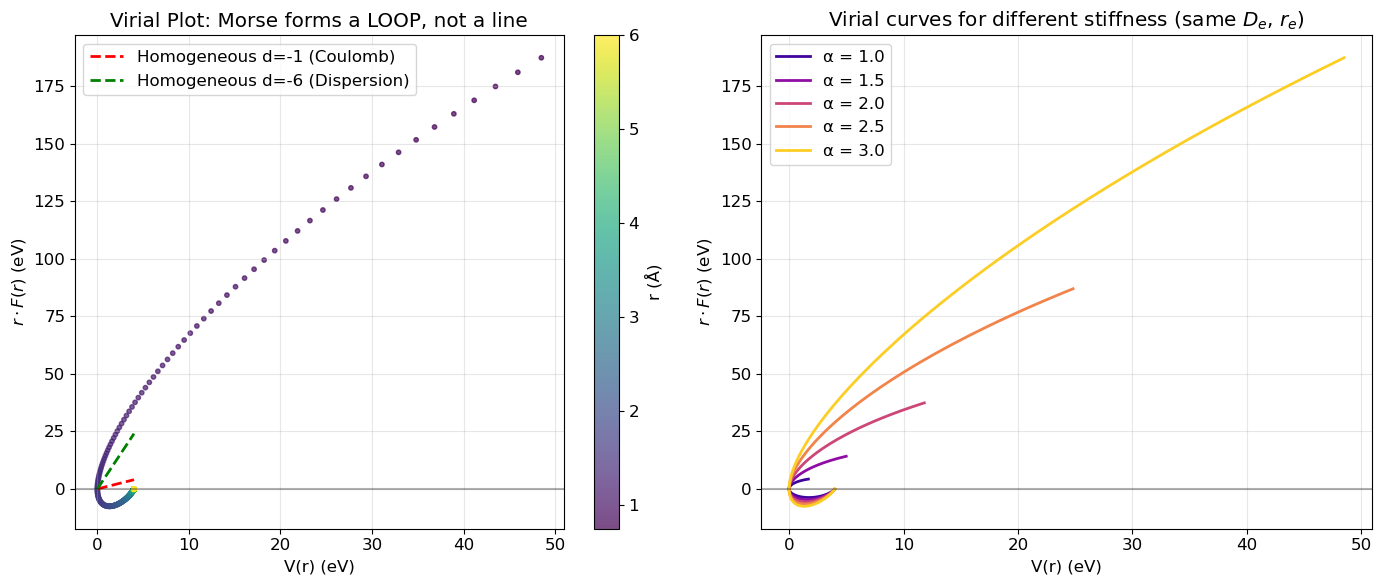

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Parameters
De, re, a = 4.0, 1.5, 2.0
r = np.linspace(0.5 * re, 4 * re, 500)

V = morse_potential(r, De, a, re)
F = morse_force(r, De, a, re)
virial = r * F  # This is -r * V' = -r * dV/dr

# Left: The Virial Plot for Morse
ax = axes[0]
ax.scatter(V, virial, c=r, cmap='viridis', s=10, alpha=0.7)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('r (Å)')

# For comparison: what a homogeneous d=-1 (Coulomb) would look like
V_line = np.linspace(0, De, 100)
ax.plot(V_line, 1 * V_line, 'r--', linewidth=2, label='Homogeneous d=-1 (Coulomb)')
ax.plot(V_line, 6 * V_line, 'g--', linewidth=2, label='Homogeneous d=-6 (Dispersion)')

ax.set_xlabel('V(r) (eV)')
ax.set_ylabel('$r \\cdot F(r)$ (eV)')
ax.set_title('Virial Plot: Morse forms a LOOP, not a line')
ax.legend()
ax.axhline(0, color='k', linestyle='-', alpha=0.3)

# Right: Compare multiple stiffnesses
ax = axes[1]
stiffness_values = [1.0, 1.5, 2.0, 2.5, 3.0]
colors = cm.plasma(np.linspace(0.1, 0.9, len(stiffness_values)))

for alpha, color in zip(stiffness_values, colors):
    a = alpha / re
    V = morse_potential(r, De, a, re)
    F = morse_force(r, De, a, re)
    virial = r * F
    ax.plot(V, virial, color=color, linewidth=2, label=f'α = {alpha}')

ax.set_xlabel('V(r) (eV)')
ax.set_ylabel('$r \\cdot F(r)$ (eV)')
ax.set_title('Virial curves for different stiffness (same $D_e$, $r_e$)')
ax.legend()
ax.axhline(0, color='k', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Summary and Key Findings

Let's summarize what we've learned.

In [29]:
print("="*70)
print("SUMMARY: Adaptive Homogeneity for Morse Potentials")
print("="*70)
print("")
print("KEY FINDING 1: Corresponding States WORKS")
print("-" * 50)
print("The effective homogeneity degree k_eff depends ONLY on:")
print("  • ρ = r/re (reduced distance)")
print("  • α = a·re (stiffness parameter)")
print("")
print("It does NOT depend on De! The well depth scales out completely.")
print("")
print("Universal formula: k_eff(ρ;α) = 2α·ρ·e^{-α(ρ-1)} / (1 - e^{-α(ρ-1)})")
print("")
print("="*70)
print("")
print("KEY FINDING 2: The Singularity at ρ=1")
print("-" * 50)
print("k_eff has a SIMPLE POLE at ρ=1 (equilibrium):")
print("  k_eff ≈ 2/(ρ-1) + 2 + O(ρ-1)")
print("")
print("The pole has RESIDUE 2 (independent of α!)")
print("")
print("REGULARIZATION OPTIONS:")
print("  1. Learn g(ρ) = (ρ-1)·k_eff  [smooth, g(1) = 2]")
print("  2. Learn h(ρ) = k_eff - 2/(ρ-1)  [smooth, h(1) = 2]")
print("  3. Exclude near-equilibrium region and interpolate")
print("")
print("="*70)
print("")
print("KEY FINDING 3: Recovery via Integration")
print("-" * 50)
print("V(r) can be recovered from k_eff via:")
print("  V(r) = V(r₀) · exp(∫_{r₀}^{r} k_eff(x)/x dx)")
print("")
print("Using boundary condition V(∞) → De works well.")
print("The singularity at ρ=1 is integrable (simple pole).")
print("")
print("="*70)
print("")
print("IMPLICATIONS FOR ML:")
print("-" * 50)
print("1. DIMENSIONALITY REDUCTION: Instead of learning V(r; De, a, re),")
print("   learn just g(ρ; α) - a 1D function of one parameter!")
print("")
print("2. DATA EFFICIENCY: All Morse potentials with same α collapse.")
print("   Training on one teaches all.")
print("")
print("3. TRANSFERABILITY: The universal curve extrapolates naturally.")
print("")
print("="*70)
print("")
print("OPEN QUESTIONS FOR DISCUSSION WITH ANATOLE:")
print("-" * 50)
print("1. Which regularization (g or h) is more physically meaningful?")
print("2. How does this extend to many-body systems?")
print("3. Connection to Rose equation / UBER?")
print("4. Best way to handle integration near the singularity?")

SUMMARY: Adaptive Homogeneity for Morse Potentials

KEY FINDING 1: Corresponding States WORKS
--------------------------------------------------
The effective homogeneity degree k_eff depends ONLY on:
  • ρ = r/re (reduced distance)
  • α = a·re (stiffness parameter)

It does NOT depend on De! The well depth scales out completely.

Universal formula: k_eff(ρ;α) = 2α·ρ·e^{-α(ρ-1)} / (1 - e^{-α(ρ-1)})


KEY FINDING 2: The Singularity at ρ=1
--------------------------------------------------
k_eff has a SIMPLE POLE at ρ=1 (equilibrium):
  k_eff ≈ 2/(ρ-1) + 2 + O(ρ-1)

The pole has RESIDUE 2 (independent of α!)

REGULARIZATION OPTIONS:
  1. Learn g(ρ) = (ρ-1)·k_eff  [smooth, g(1) = 2]
  2. Learn h(ρ) = k_eff - 2/(ρ-1)  [smooth, h(1) = 2]
  3. Exclude near-equilibrium region and interpolate


KEY FINDING 3: Recovery via Integration
--------------------------------------------------
V(r) can be recovered from k_eff via:
  V(r) = V(r₀) · exp(∫_{r₀}^{r} k_eff(x)/x dx)

Using boundary condition